## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Importing from files

In [2]:
import sys
import os

# Move up to the parent directory of 'notebookDir'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from axion_production.parameter_dependence import ParametersAxionMassDependence
from axion_production.taon_decay.taon_decay_analysis import TaonDecayModel

In [3]:
# --- IMPORTING MAXIM DELTA NEFF CALCULATIONS
# Load the data from file
filename = "../Maxim-data/dNeff_fa_tau_dec.dat"  # Set the correct file path

# Read data while skipping the first row (header)
data = np.loadtxt(filename, delimiter=",", skiprows=1)

# Extract the first and third columns
fa_arr_MAXIM = data[:, 0]  # First column
delta_Neff_MAXIM = data[:, 2]  # Third column

N_distribution_Maxim = len(fa_arr_MAXIM)

## Initialize the Axion Taon Decay Model

In [4]:
file_path = '../Maxim-data/Distributions_fa_tau_dec.dat'  # Set the correct file path
muonScattering = TaonDecayModel(file_path)
parameterDependence = ParametersAxionMassDependence("taon_decay", file_path)

In [5]:
# --- Find ΔN_eff: using Parameters A, b and mu fitted to the original distribution
N_distributions = parameterDependence.get_number_of_distributions()

# --- Necessary list and loop
delta_Neff_points_arr = []
mass_axion_points_arr = []
decay_cons_points_arr = []

for index in range(0, N_distributions):
    # return axion mass and fa
    axion_mass = parameterDependence.get_axion_masses()[index]
    decay_cons = parameterDependence.get_decay_constants()[index]

    # Find parameters A, b, mu after comparing to original distribution
    fit_params = parameterDependence.fit_single_distribution(index, dist="f(q)_q2")

    # calculate delta N_eff
    delta_N_eff = muonScattering.calculate_delta_n_eff(axion_mass, parameters_arr=fit_params)

    # appending
    delta_Neff_points_arr.append(delta_N_eff)
    mass_axion_points_arr.append(axion_mass)
    decay_cons_points_arr.append(decay_cons)

In [6]:
# --- Find ΔN_eff: using analytical formula for A(log(m_a)), b(log(m_a)) and mu(log(m_a))
# axion masses
low_axion_mass = min(mass_axion_points_arr)
max_axion_mass = max(mass_axion_points_arr)
Nums = 500
axion_masses = np.logspace(np.log10(low_axion_mass), np.log10(max_axion_mass), num=Nums)  # [eV]

# --- find the values of Delta N_eff
delta_N_eff_arr = []
decay_constants_arr = []
for m_a in axion_masses:
    val_fa = muonScattering.calculate_fa(m_a)
    
    # calculate delta N_eff
    delta_N_eff = muonScattering.calculate_delta_n_eff(m_a)

    # appending
    delta_N_eff_arr.append(delta_N_eff)
    decay_constants_arr.append(val_fa)

In [7]:
muonScattering.get_q_tilda_upper_limit()

31.285920644378724

## Extra Relativistic Degrees of Freedom and Axion Mass: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$

This plot compares $\Delta N_{\mathrm{eff}}$ computed from the **analytical formula** and from **directly extracted distributions** as functions of:
- **Axion mass** $m_a$ (left panel).
- **Decay constant** $f_a$ (right panel).

### **Features**
- **Comparison of two methods**: analytical (solid line) vs. distribution-based (scatter points).
- **Planck 2018 constraint** added as a reference (dashed line and shaded region).

This visualization checks the consistency between the interpolated and direct methods, confirming that the functional approximations for $A(m_a), b(m_a), \mu(m_a)$ correctly describe the axion distribution and its effect on $\Delta N_{\mathrm{eff}}$.

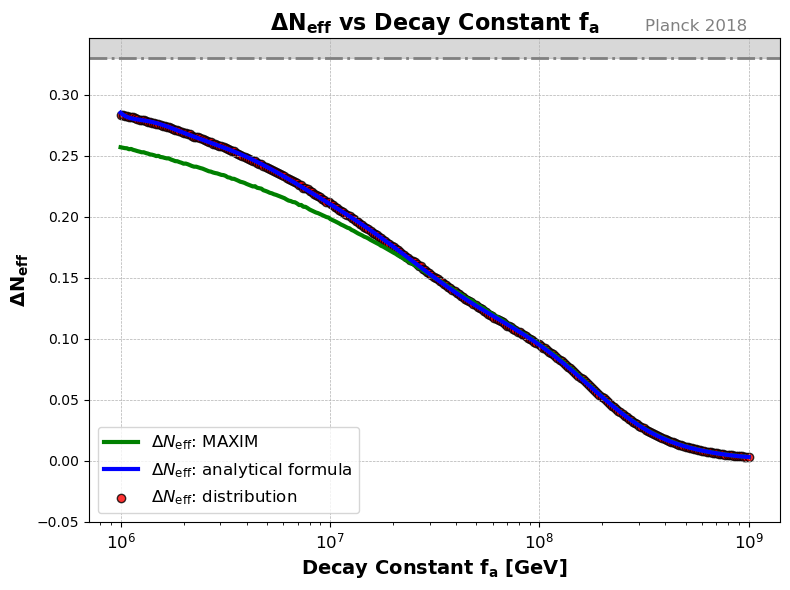

In [8]:
# Create the figure and two subplots with improved aesthetics
fig, axs = plt.subplots(figsize=(8, 6))

# ---------------------------------------------------- SECOND PART OF PLOT ---------------------------------------------------- #
# Second plot: f_a vs Delta_N_eff with larger font size and thicker lines
axs.plot(fa_arr_MAXIM, delta_Neff_MAXIM, color='g', lw=3, label=r'$\Delta N_{\rm{eff}}$: MAXIM')
axs.plot(decay_constants_arr, delta_N_eff_arr, color='b', lw=3, label=r'$\Delta N_{\rm{eff}}$: analytical formula')
axs.scatter(decay_cons_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')
axs.set_xscale('log')
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs.set_title(r'$\bf \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
axs.grid(True, linestyle='--', linewidth=0.5)
axs.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs.text(decay_constants_arr[1], planck_limit + 0.02, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs.get_ylim()
xmin, xmax = axs.get_xlim()
axs.set_xlim(xmin, xmax)
axs.set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SAVING PLOT ---------------------------------------------------- #
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# plt.savefig('delta_N_eff_vs_axion_mass_and_decay_constant_new.png', format='png', dpi=300)
# plt.close()

In [9]:
# --- Check the differences between ΔN_eff_fit and ΔN_eff_points ---
print(f"{'Axion Mass [eV]':<20}{'ΔN_eff (Best)':>20}{'ΔN_eff (Fit)':>20}{'Rel. Diff. [%]':>20}")
print("=" * 80)

rel_diff_arr = []
for i in range(N_distribution_Maxim):
    fa = fa_arr_MAXIM[i]
    m_a = muonScattering.calculate_ma(fa)

    # Find delta Neff
    N_eff = delta_Neff_MAXIM[i]  # Best values from distribution
    N_eff_fit = muonScattering.calculate_delta_n_eff(m_a)

    # Compute relative difference in percentage
    rel_diff = 100 * abs(N_eff - N_eff_fit) / abs(N_eff) if N_eff != 0 else 0
    rel_diff_arr.append(rel_diff)

    print(f"{m_a:<20.6e}{N_eff:>20.6e}{N_eff_fit:>20.6e}{rel_diff:>20.6f}")

Axion Mass [eV]            ΔN_eff (Best)        ΔN_eff (Fit)      Rel. Diff. [%]
5.691000e+00                2.570522e-01        2.853381e-01           11.003939
5.561029e+00                2.566605e-01        2.839064e-01           10.615540
5.434026e+00                2.563464e-01        2.828046e-01           10.321291
5.309923e+00                2.562181e-01        2.819607e-01           10.047144
5.188655e+00                2.554176e-01        2.813143e-01           10.138965
5.070156e+00                2.556854e-01        2.808156e-01            9.828586
4.954364e+00                2.549018e-01        2.804230e-01           10.012195
4.841216e+00                2.544612e-01        2.801025e-01           10.076675
4.730652e+00                2.539007e-01        2.798260e-01           10.210810
4.622613e+00                2.534704e-01        2.795713e-01           10.297401
4.517042e+00                2.529394e-01        2.793205e-01           10.429838
4.413882e+00                

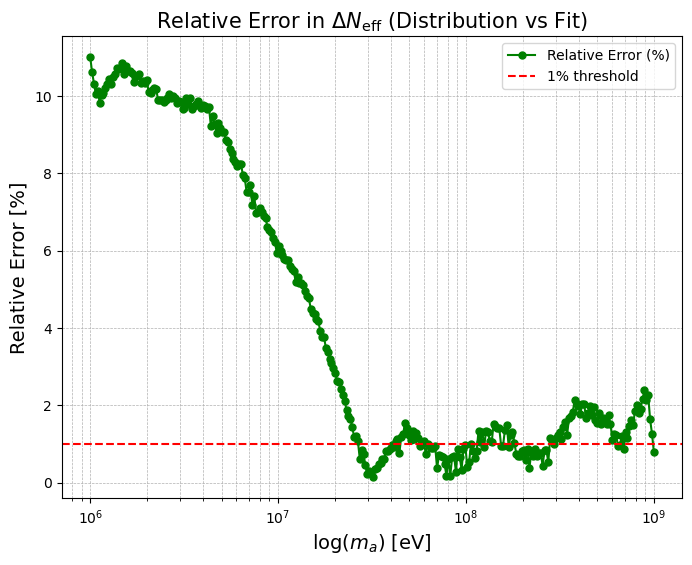

In [10]:
# Convert axion masses to log scale
log_masses = np.log10(axion_masses)

plt.figure(figsize=(8, 6))

# Plot relative error as a function of axion mass
plt.plot(fa_arr_MAXIM, rel_diff_arr, 'go-', label=r'Relative Error (%)', markersize=5)

# Add a horizontal line at 1% to highlight the accuracy threshold
plt.axhline(y=1, color='r', linestyle='--', label='1% threshold')

plt.xlabel(r'$\log(m_a)$ [eV]', fontsize=14)
plt.ylabel(r'Relative Error [%]', fontsize=14)
plt.title(r'Relative Error in $\Delta N_{\mathrm{eff}}$ (Distribution vs Fit)', fontsize=15)

# Use logarithmic y-scale if errors span multiple orders of magnitude
plt.xscale("log")  

plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()